## Лабораторная работа Nº5.


Разработка имитационной модели двухканальной вычислительной системы с
отказами.
Сопоставление результатов работы имитационной модели и аналитических результатов, полученных на основе теории массового обслуживания.

## Задание №1

Разработать компьютерную программу для имитационного моделирования двухканальной системы с отказами.

In [54]:
import numpy as np
import pandas as pd
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def simulate_system(lmbda, mu, T):
    t = 0

    # моменты окончания обслуживания
    channel1_busy_until = 0
    channel2_busy_until = 0

    served = 0
    rejected = 0

    idle_time_1 = 0
    idle_time_2 = 0

    last_event_time = 0

    while t < T:
        interarrival = np.random.exponential(1 / lmbda)
        t += interarrival

        if t > T:
            break

        # считаем простой каналов
        if channel1_busy_until < t:
            idle_time_1 += t - max(channel1_busy_until, last_event_time)

        if channel2_busy_until < t:
            idle_time_2 += t - max(channel2_busy_until, last_event_time)

        last_event_time = t

        # распределяем заявку
        if t >= channel1_busy_until:

            service_time = np.random.exponential(1 / mu)
            channel1_busy_until = t + service_time
            served += 1

        elif t >= channel2_busy_until:

            service_time = np.random.exponential(1 / mu)
            channel2_busy_until = t + service_time
            served += 1

        else:

            rejected += 1
    if channel1_busy_until < T:
        idle_time_1 += T - max(channel1_busy_until, last_event_time)

    if channel2_busy_until < T:
        idle_time_2 += T - max(channel2_busy_until, last_event_time)

    total = served + rejected

    # вероятности
    Pf = rejected / total
    Q = served / total

    # вероятности простоя
    idle_prob1 = idle_time_1 / T
    idle_prob2 = idle_time_2 / T

    # загрузка каналов
    load1 = 1 - idle_prob1
    load2 = 1 - idle_prob2

    # загрузка хотя бы одного канала
    load_any = 2 - (idle_prob1 + idle_prob2)

    return {
        "served": served,
        "rejected": rejected,

        "Q": Q,
        "Pf": Pf,

        "idle_time_1": idle_time_1,
        "idle_time_2": idle_time_2,

        "idle_prob1": idle_prob1,
        "idle_prob2": idle_prob2,

        "load1": load1,
        "load2": load2,

        "load_any": load_any
    }

## Задание №2

In [55]:
lmbda = 0.2
mu = 0.1
T = 1000

result = simulate_system(lmbda, mu, T)

print("Число обработанных заявок:", result["served"])
print("Число отказов:", result["rejected"])

print("\nВероятности:")
print("Вероятность обработки заявки Q =", result["Q"])
print("Вероятность отказа Pf =", result["Pf"])

print("\nВремя простоя каналов:")
print("Простой 1 канала =", result["idle_time_1"])
print("Простой 2 канала =", result["idle_time_2"])

print("\nВероятности загрузки:")
print("Загрузка 1 канала =", result["load1"])
print("Загрузка 2 канала =", result["load2"])

print("\nКоэффициент загрузки каналов =",
      result["load_any"])

Число обработанных заявок: 127
Число отказов: 89

Вероятности:
Вероятность обработки заявки Q = 0.5879629629629629
Вероятность отказа Pf = 0.41203703703703703

Время простоя каналов:
Простой 1 канала = 284.32309937889386
Простой 2 канала = 429.19808620774586

Вероятности загрузки:
Загрузка 1 канала = 0.7156769006211061
Загрузка 2 канала = 0.5708019137922542

Коэффициент загрузки каналов = 1.2864788144133603


## Задание №3

In [56]:
# 3.1

def analytical_results(lmbda, mu):
    rho = lmbda / mu # коэффициент загрузки системы
    P0 = 1 / (1 + rho + rho**2 / 2) # вероятность простоя системы (оба канала свободны)
    Pf = (rho**2 / 2) * P0 # вероятность отказа (оба канала заняты)
    Q = 1 - Pf # вероятность обработки заявки (хотя бы один канал свободен)
    A = Q * lmbda # абсолютная пропускная способность (система реально обрабатывает заявки)
    k = A / mu # коэффициент загрузки каналов (хотя бы один канал занят)

    return {
        "rho": rho,
        "P0": P0,
        "Pf": Pf,
        "Q": Q,
        "A": A,
        "k": k
    }

analytical = analytical_results(lmbda, mu)

labels = {
    "rho": "rho — коэффициент загрузки системы (lambda/mu)",
    "P0":  "P0  — вероятность простоя системы (оба канала свободны)",
    "Pf":  "Pf  — вероятность отказа (оба канала заняты)",
    "Q":   "Q   — относительная пропускная способность (1 - Pf)",
    "A":   "A   — абсолютная пропускная способность (Q * lambda)",
    "k":   "k   — коэффициент загрузки каналов (A / mu) ",
}

print("Аналитические результаты:")
for key, v in analytical.items():
    print(f"  {labels[key]} = {v}")


print("\nИмитационная модель:")
print("  Pf  — вероятность отказа                               =", result["Pf"])
print("  Q   — относительная пропускная способность              =", result["Q"])
print("  k   — коэффициент загрузки каналов                      =", result["load_any"])

print("\nОтклонение имитации от аналитики:")
print(f"  Pf: {abs(result['Pf'] - analytical['Pf']) / analytical['Pf'] * 100:.2f}%")
print(f"  Q:  {abs(result['Q']  - analytical['Q'])  / analytical['Q']  * 100:.2f}%")
print(f"  k:  {abs(result['load_any'] - analytical['k']) / analytical['k'] * 100:.2f}%")


Аналитические результаты:
  rho — коэффициент загрузки системы (lambda/mu) = 2.0
  P0  — вероятность простоя системы (оба канала свободны) = 0.2
  Pf  — вероятность отказа (оба канала заняты) = 0.4
  Q   — относительная пропускная способность (1 - Pf) = 0.6
  A   — абсолютная пропускная способность (Q * lambda) = 0.12
  k   — коэффициент загрузки каналов (A / mu)  = 1.2

Имитационная модель:
  Pf  — вероятность отказа                               = 0.41203703703703703
  Q   — относительная пропускная способность              = 0.5879629629629629
  k   — коэффициент загрузки каналов                      = 1.2864788144133603

Отклонение имитации от аналитики:
  Pf: 3.01%
  Q:  2.01%
  k:  7.21%


In [57]:
# 3.2

times = [1000, 2000, 3000, 5000]
rows = []
lmbda = 0.2
mu = 0.1
for T in times:
    res = simulate_system(lmbda, mu, T)

    rows.append([
        T,
        res["Pf"],
        res["Q"],
        res["idle_prob1"],
        res["idle_prob2"],
        res["load_any"]
    ])

df = pd.DataFrame(rows, columns=[
    "T", # время моделирования
    "Pf", # вероятность отказа в обслуживании
    "Q", # вероятность обработки заявки
    "Tr1/T", # вероятность простоя 1 канала
    "Tr2/T", # вероятность простоя 2 канала
    "Load" # коэффициент загрузки каналов
])

df

,T,Pf,Q,Tr1/T,Tr2/T,Load
0,1000,0.394595,0.605405,0.303179,0.539057,1.157764
1,2000,0.358090,0.641910,0.350654,0.519686,1.129659
2,3000,0.417618,0.582382,0.319264,0.449718,1.231017
3,5000,0.404692,0.595308,0.321502,0.479920,1.198578


Полученные результаты имитационного моделирования близки к аналитическим значениям, рассчитанным по формулам теории массового обслуживания.

Небольшие отклонения объясняются случайным характером входного потока и времени обслуживания заявок.

При увеличении времени моделирования результаты стабилизируются и приближаются к теоретическим значениям, что подтверждает корректность разработанной имитационной модели.

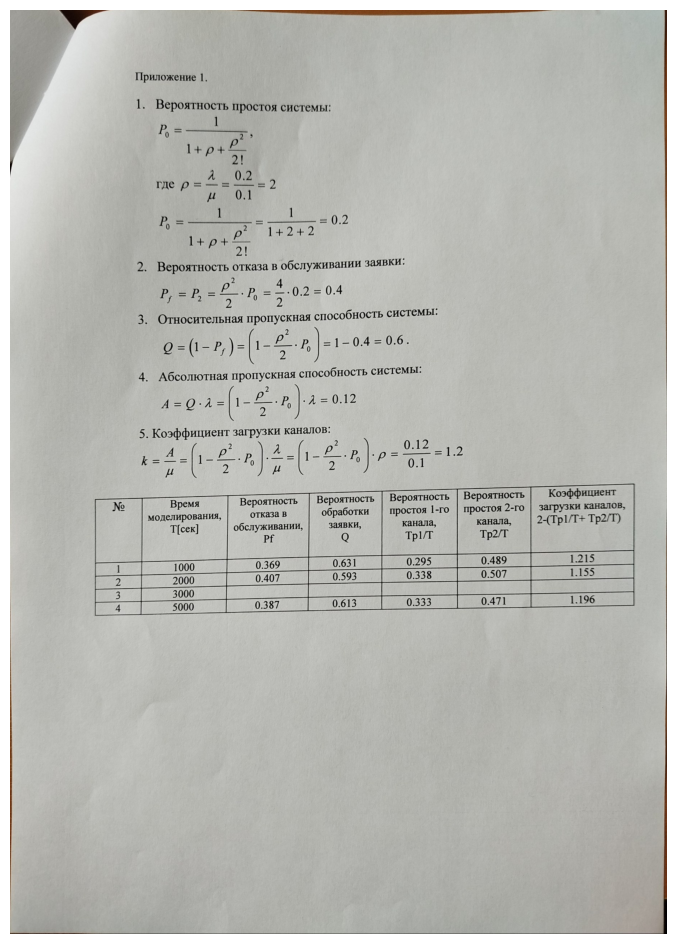

In [58]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/Users/rustamshamsut/mtuci/mtuci-highload/lab5/task/5.jpg')
plt.figure(figsize=(20, 12))
plt.imshow(img)
plt.axis('off')
plt.show()
